<a href="https://colab.research.google.com/github/kauanesv/linkedIn-queens-solver/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bibliotecas**

In [53]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# **Constantes**

In [54]:
TAMANHO_CONJUNTO = 8
QUANTIDADE_IMAGENS = 14

# **GitHub**

In [55]:
!rm -rf linkedIn-queens-solver
!git clone https://github.com/kauanesv/linkedIn-queens-solver.git
%cd linkedIn-queens-solver

Cloning into 'linkedIn-queens-solver'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 36 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 1.61 MiB | 13.47 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/linkedIn-queens-solver/linkedIn-queens-solver


# **Carrega Imagens**

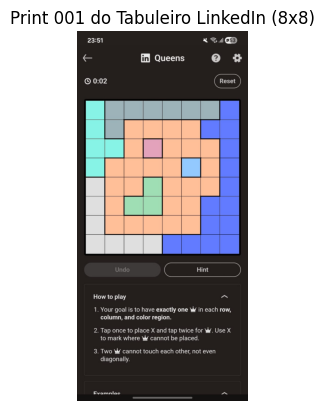

In [56]:
# função que carrega as imagens (prints) do tabuleiro
def carregar_imagens_tabuleiro(id_imagem):
  # carrega imagem do github
  print_tabuleiro = cv2.imread(f'imagens_tabuleiro/{id_imagem:03d}.jpeg')
  # exibe print de tela do tabuleiro
  plt.imshow(print_tabuleiro, cmap='gray')
  plt.title(f"Print {id_imagem:03d} do Tabuleiro LinkedIn (8x8)")
  plt.axis('off')
  plt.show()
  # retorna a imagem carregada
  return print_tabuleiro

print_tabuleiro = carregar_imagens_tabuleiro(1)

# **Recorte Automático do Tabuleiro**

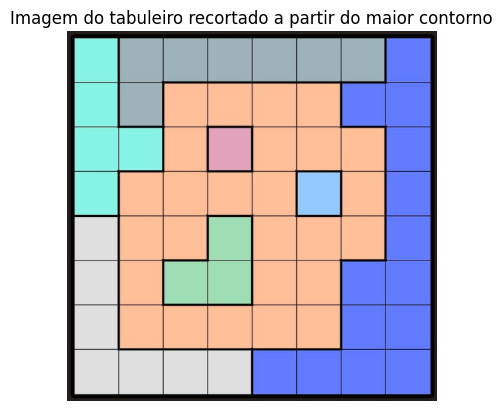

In [57]:
# função que recorta a região de interesse (tabuleiro) do print automaticamente
def recortar_imagem_tabuleiro(print_tabuleiro):
  # recorte inicial empírico
  imagem_tabuleiro = print_tabuleiro[260:1000, :]
  # converte para escala de cinza
  cinza = cv2.cvtColor(imagem_tabuleiro, cv2.COLOR_BGR2GRAY)
  # binariza a imagem recortada
  _, threshold = cv2.threshold(cinza, 30, 255, cv2.THRESH_BINARY)
  # normaliza imagem para padrão UINT8 (0 a 255)
  imagem_binaria = ((~threshold) * 255).astype(np.uint8)
  # exibe imagem binária recortada
  # plt.imshow(~threshold, cmap='gray')
  # plt.title("Imagem binária recortada empiricamente")
  # plt.axis('off')
  # plt.show()
  # encontrar os contornos da imagem binaria
  contornos, _ = cv2.findContours(imagem_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
  # cria buffer da imagem binaria para visualizar contornos
  imagem_binaria_rgb = cv2.cvtColor(imagem_binaria, cv2.COLOR_GRAY2RGB)
  cv2.drawContours(imagem_binaria_rgb, contornos, -1, (255, 0, 0), 2)
  # exibe os contornos encontrados na imagem
  # plt.figure(figsize=(12, 6))
  # plt.imshow(imagem_binaria_rgb)
  # plt.title("Contornos encontrados na imagem binária")
  # plt.axis('off')
  # plt.show()
  # guarda o maior contorno (que será o tabuleiro 8x8)
  maior_contorno = max(contornos, key=cv2.contourArea)
  # guarda informações geométricas do contorno encontrado (dimensões do quadrado/tabuleiro)
  x, y, w, h = cv2.boundingRect(maior_contorno)
  # recortar apenas a região do tabuleiro
  tabuleiro_recortado = imagem_tabuleiro[y:y+h, x:x+w]
  # exibe tabuleiro recortado
  plt.imshow(tabuleiro_recortado, cmap='gray')
  plt.title("Imagem do tabuleiro recortado a partir do maior contorno")
  plt.axis('off')
  plt.show()
  # retorna o tabuleiro recortado
  return tabuleiro_recortado

tabuleiro_recortado = recortar_imagem_tabuleiro(print_tabuleiro)

# **Matriz do Tabuleiro**

In [58]:
# função que gera a matriz de cores do tabuleiro a partir da imagem do tabuleiro
def gerar_matriz_tabuleiro(tabuleiro_recortado):
  # redimensiona o tabuleiro para um tamanho fixo padrão para facilitar os cálculos
  tabuleiro_padrao = cv2.resize(tabuleiro_recortado, (400, 400))
  # calcula o tamanho aproximado de cada célula (quadradinho no tabuleiro)
  tamanho_celula = 400 // 8
  # inicia lista que amazenará as cores de cada célula
  cores_tabuleiro = []
  # percorre todo o tabuleiro (linhas x colunas)
  for linha in range(TAMANHO_CONJUNTO):
    for coluna in range(TAMANHO_CONJUNTO):
      # calcula o pixel central exato de cada quadradinho para evitar pegar as linhas pretas da borda
      centro_y = (linha * tamanho_celula) + (tamanho_celula // 2)
      centro_x = (coluna * tamanho_celula) + (tamanho_celula // 2)
      # coleta a cor daquele ponto/célula no tabuleiro
      cor_pixel = tabuleiro_padrao[centro_y, centro_x]
      # guarda a cor na lista de cores das células (quadradinho)
      cores_tabuleiro.append(cor_pixel)
  # aplica algoritmo de clusterização sobre a lista de cores das células/quadradinhos
  # K = 8 (clusters) e semente fixa (42)
  kmeans = KMeans(n_clusters=8, random_state=42)
  # armezena predição de clusters da lista de cores do tabuleiro
  labels_cores = kmeans.fit_predict(cores_tabuleiro)
  # transformar a lista de 64 resultados em uma matriz 8x8
  tabuleiro_matriz_cores = labels_cores.reshape(8, 8)
  # exibe mapeamento da matriz do tabuleiro
  print("\nMapeamento dos quadradinhos (matriz):")
  print(tabuleiro_matriz_cores)
  print("\n")
  # exibe tabuleiro recortado para comparação com matriz
  # plt.imshow(tabuleiro_padrao, cmap='gray')
  # plt.title("Imagem do tabuleiro recortado")
  # plt.axis('off')
  # plt.show()
  # retorna matriz mapeada do tabuleiro
  return tabuleiro_matriz_cores

matriz_tabuleiro = gerar_matriz_tabuleiro(tabuleiro_recortado)


Mapeamento dos quadradinhos (matriz):
[[4 2 2 2 2 2 2 0]
 [4 2 1 1 1 1 0 0]
 [4 4 1 6 1 1 1 0]
 [4 1 1 1 1 7 1 0]
 [3 1 1 5 1 1 1 0]
 [3 1 5 5 1 1 0 0]
 [3 1 1 1 1 1 0 0]
 [3 3 3 3 0 0 0 0]]




# **Cálculo de Conflitos**

In [59]:
# função que calcula conflitos de rainhas no tabuleiro
def calcular_conflitos(estado, tabuleiro_cores):
  # inicia com 0 conflitos
  conflitos = 0
  # percorre as as posições no tabuleiro
  for i in range(TAMANHO_CONJUNTO):
    for j in range(i + 1, TAMANHO_CONJUNTO):
      # verifica se há rainhas em diagonais adjacentes
      if abs(i - j) == 1 and abs(estado[i] - estado[j]) == 1:
        conflitos += 1
      # guarda a cor (grupo) que pertencem duas rainhas
      cor_rainha1 = tabuleiro_cores[i][estado[i]]
      cor_rainha2 = tabuleiro_cores[j][estado[j]]
      # verifica se essas duas rainhas estão na mesma cor (grupo)
      if cor_rainha1 == cor_rainha2:
        conflitos += 1
      # verifica se há rainhas na mesma linha
      if estado[i] == estado[j]:
        conflitos += 1
  # exibe a quantidade de conflitos no tabuleiro
  print(f"Quantidade de conflitos: {conflitos}\n")
  # retorna a quantidade de conflitos
  return conflitos

# estado aleatório para teste
estado = [1, 3, 4, 7, 0, 2, 5, 6]
conflitos = calcular_conflitos(estado, matriz_tabuleiro)

Quantidade de conflitos: 6



# **Pipeline**

########################################################################
####################### MAPEAMENTO TABULEIRO 001 #######################
########################################################################



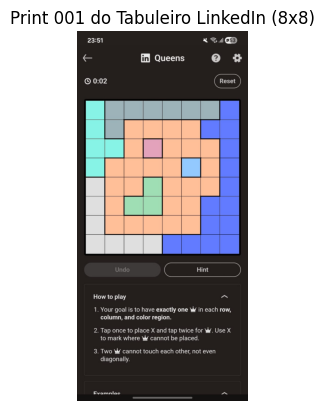

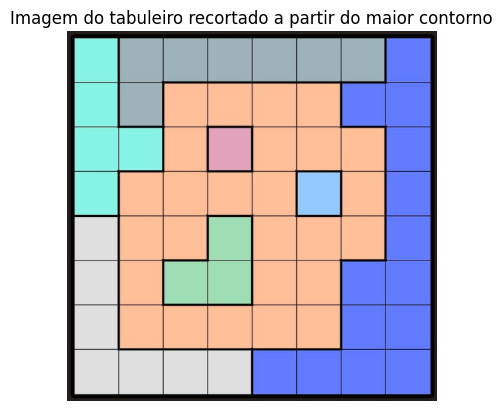


Mapeamento dos quadradinhos (matriz):
[[4 2 2 2 2 2 2 0]
 [4 2 1 1 1 1 0 0]
 [4 4 1 6 1 1 1 0]
 [4 1 1 1 1 7 1 0]
 [3 1 1 5 1 1 1 0]
 [3 1 5 5 1 1 0 0]
 [3 1 1 1 1 1 0 0]
 [3 3 3 3 0 0 0 0]]


Quantidade de conflitos: 6

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 002 #######################
########################################################################



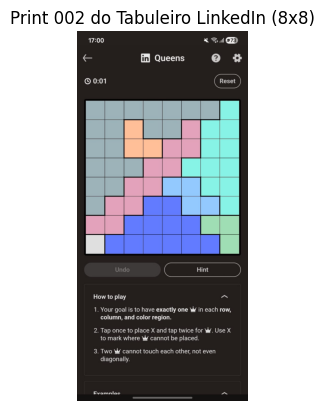

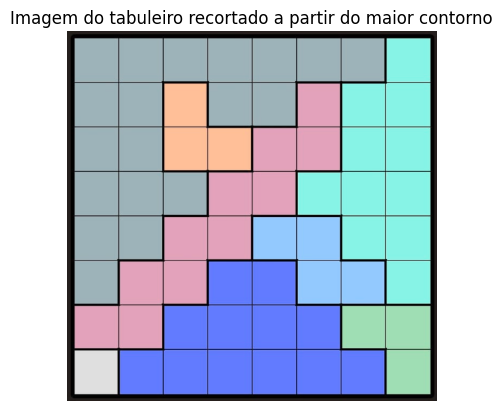


Mapeamento dos quadradinhos (matriz):
[[1 1 1 1 1 1 1 0]
 [1 1 5 1 1 3 0 0]
 [1 1 5 5 3 3 0 0]
 [1 1 1 3 3 0 0 0]
 [1 1 3 3 4 4 0 0]
 [1 3 3 2 2 4 4 0]
 [3 3 2 2 2 2 6 6]
 [7 2 2 2 2 2 2 6]]


Quantidade de conflitos: 7

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 003 #######################
########################################################################



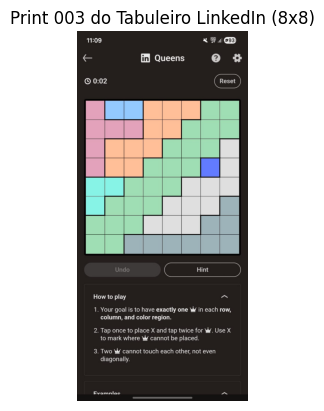

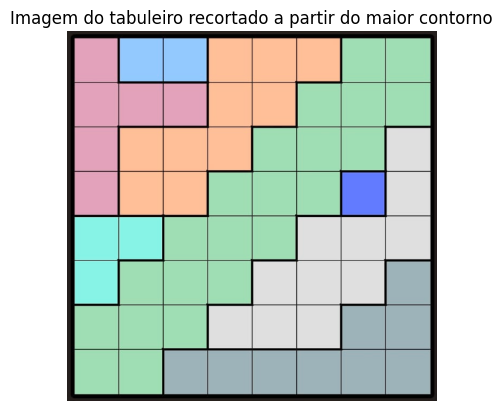


Mapeamento dos quadradinhos (matriz):
[[4 5 5 2 2 2 3 3]
 [4 4 4 2 2 3 3 3]
 [4 2 2 2 3 3 3 0]
 [4 2 2 3 3 3 6 0]
 [7 7 3 3 3 0 0 0]
 [7 3 3 3 0 0 0 1]
 [3 3 3 0 0 0 1 1]
 [3 3 1 1 1 1 1 1]]


Quantidade de conflitos: 4

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 004 #######################
########################################################################



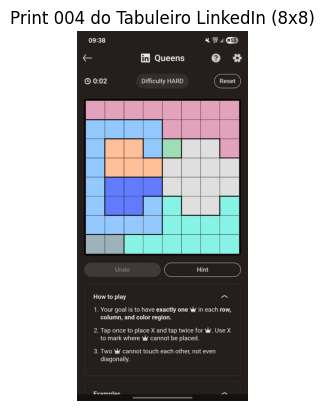

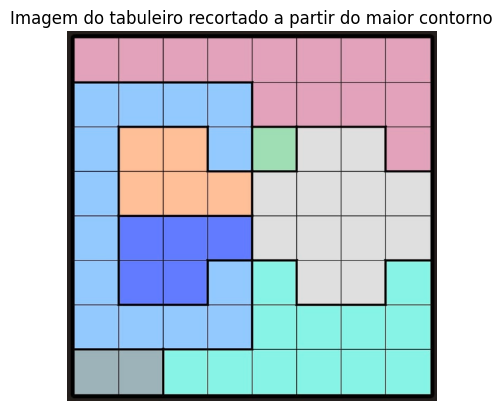


Mapeamento dos quadradinhos (matriz):
[[0 0 0 0 0 0 0 0]
 [2 2 2 2 0 0 0 0]
 [2 5 5 2 7 3 3 0]
 [2 5 5 5 3 3 3 3]
 [2 4 4 4 3 3 3 3]
 [2 4 4 2 1 3 3 1]
 [2 2 2 2 1 1 1 1]
 [6 6 1 1 1 1 1 1]]


Quantidade de conflitos: 4

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 005 #######################
########################################################################



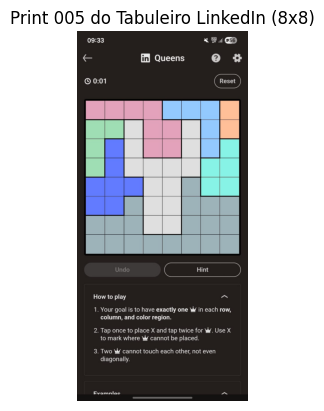

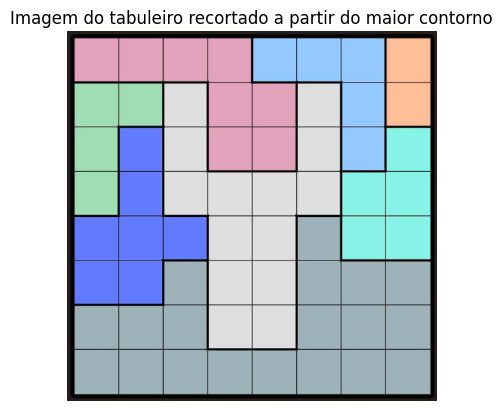


Mapeamento dos quadradinhos (matriz):
[[4 4 4 4 5 5 5 7]
 [6 6 2 4 4 2 5 7]
 [6 3 2 4 4 2 5 0]
 [6 3 2 2 2 2 0 0]
 [3 3 3 2 2 1 0 0]
 [3 3 1 2 2 1 1 1]
 [1 1 1 2 2 1 1 1]
 [1 1 1 1 1 1 1 1]]


Quantidade de conflitos: 8

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 006 #######################
########################################################################



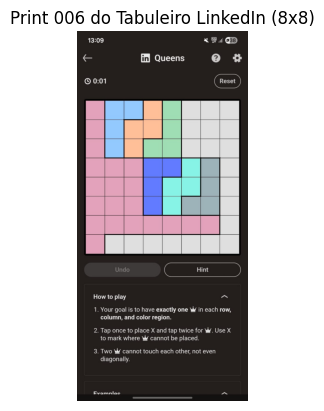

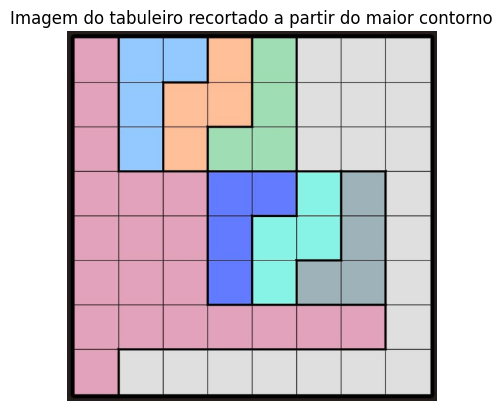


Mapeamento dos quadradinhos (matriz):
[[1 2 2 5 7 0 0 0]
 [1 2 5 5 7 0 0 0]
 [1 2 5 7 7 0 0 0]
 [1 1 1 4 4 6 3 0]
 [1 1 1 4 6 6 3 0]
 [1 1 1 4 6 3 3 0]
 [1 1 1 1 1 1 1 0]
 [1 0 0 0 0 0 0 0]]


Quantidade de conflitos: 6

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 007 #######################
########################################################################



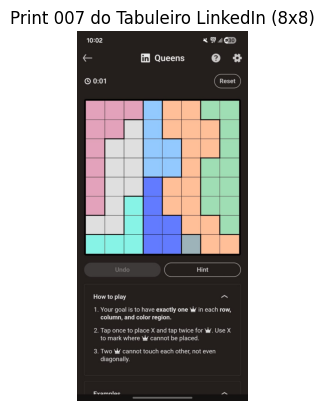

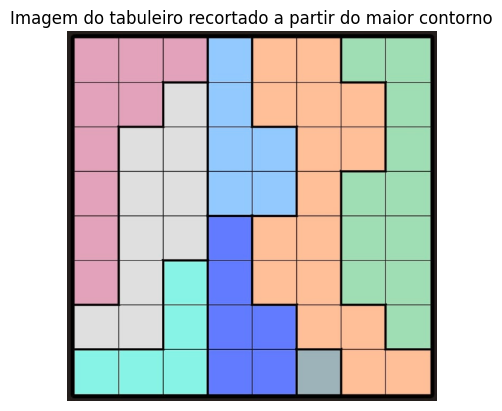


Mapeamento dos quadradinhos (matriz):
[[5 5 5 4 2 2 0 0]
 [5 5 1 4 2 2 2 0]
 [5 1 1 4 4 2 2 0]
 [5 1 1 4 4 2 0 0]
 [5 1 1 3 2 2 0 0]
 [5 1 6 3 2 2 0 0]
 [1 1 6 3 3 2 2 0]
 [6 6 6 3 3 7 2 2]]


Quantidade de conflitos: 5

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 008 #######################
########################################################################



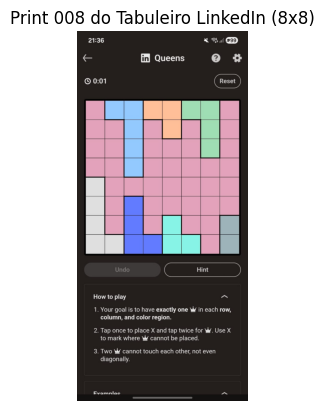

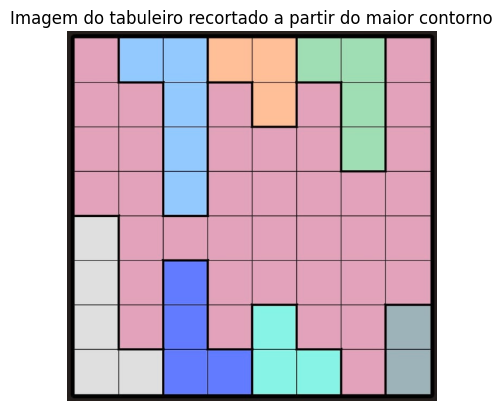


Mapeamento dos quadradinhos (matriz):
[[0 5 5 6 6 4 4 0]
 [0 0 5 0 6 0 4 0]
 [0 0 5 0 0 0 4 0]
 [0 0 5 0 0 0 0 0]
 [3 0 0 0 0 0 0 0]
 [3 0 2 0 0 0 0 0]
 [3 0 2 0 1 0 0 7]
 [3 3 2 2 1 1 0 7]]


Quantidade de conflitos: 12

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 009 #######################
########################################################################



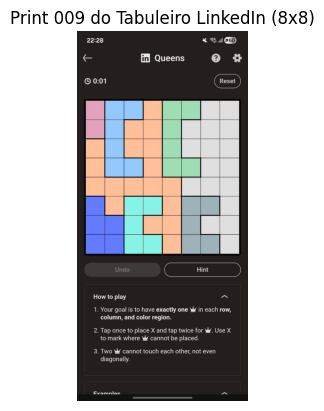

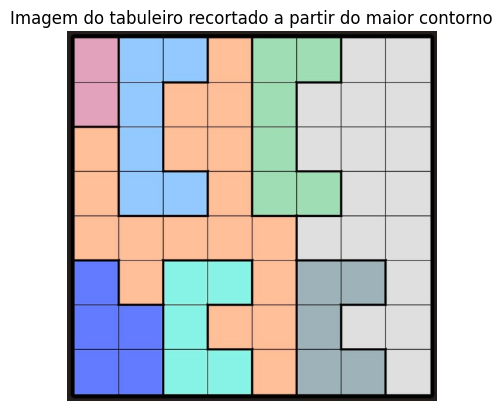


Mapeamento dos quadradinhos (matriz):
[[7 5 5 2 4 4 0 0]
 [7 5 2 2 4 0 0 0]
 [2 5 2 2 4 0 0 0]
 [2 5 5 2 4 4 0 0]
 [2 2 2 2 2 0 0 0]
 [3 2 1 1 2 6 6 0]
 [3 3 1 2 2 6 0 0]
 [3 3 1 1 2 6 6 0]]


Quantidade de conflitos: 4

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 010 #######################
########################################################################



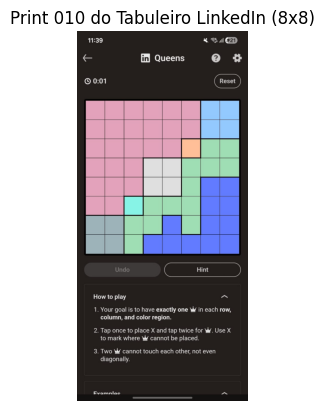

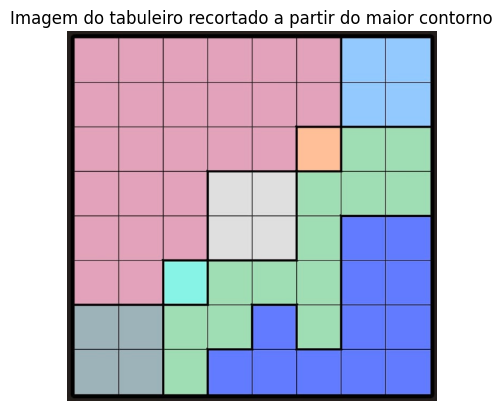


Mapeamento dos quadradinhos (matriz):
[[2 2 2 2 2 2 3 3]
 [2 2 2 2 2 2 3 3]
 [2 2 2 2 2 6 0 0]
 [2 2 2 4 4 0 0 0]
 [2 2 2 4 4 0 1 1]
 [2 2 7 0 0 0 1 1]
 [5 5 0 0 1 0 1 1]
 [5 5 0 1 1 1 1 1]]


Quantidade de conflitos: 9

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 011 #######################
########################################################################



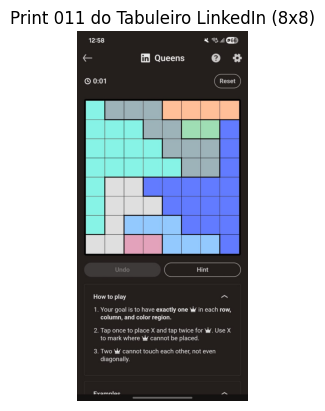

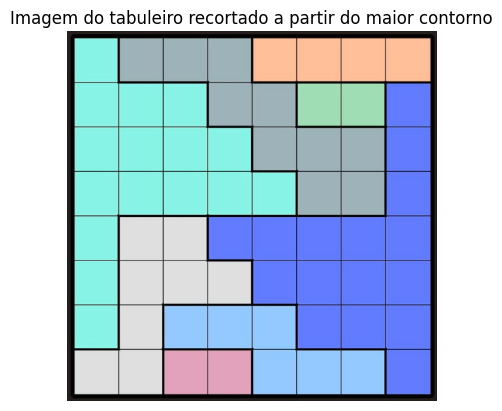


Mapeamento dos quadradinhos (matriz):
[[1 3 3 3 6 6 6 6]
 [1 1 1 3 3 7 7 0]
 [1 1 1 1 3 3 3 0]
 [1 1 1 1 1 3 3 0]
 [1 4 4 0 0 0 0 0]
 [1 4 4 4 0 0 0 0]
 [1 4 5 5 5 0 0 0]
 [4 4 2 2 5 5 5 0]]


Quantidade de conflitos: 6

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 012 #######################
########################################################################



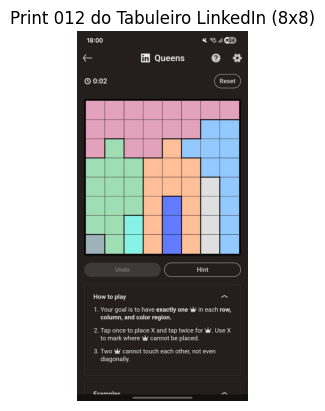

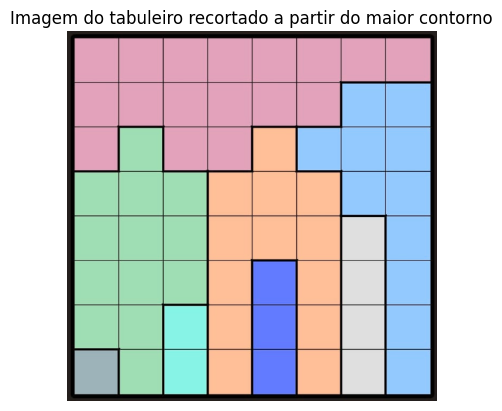


Mapeamento dos quadradinhos (matriz):
[[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 0 0]
 [1 2 1 1 3 0 0 0]
 [2 2 2 3 3 3 0 0]
 [2 2 2 3 3 3 5 0]
 [2 2 2 3 4 3 5 0]
 [2 2 6 3 4 3 5 0]
 [7 2 6 3 4 3 5 0]]


Quantidade de conflitos: 5

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 013 #######################
########################################################################



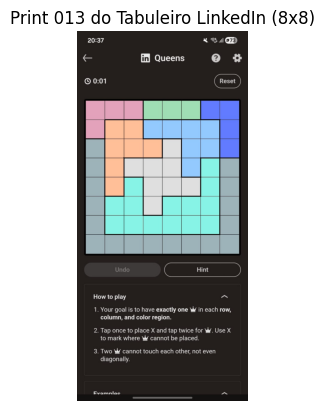

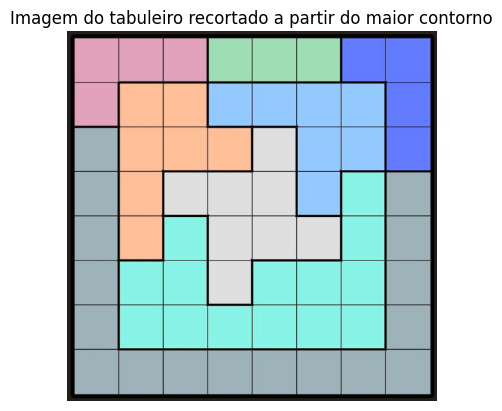


Mapeamento dos quadradinhos (matriz):
[[3 3 3 7 7 7 0 0]
 [3 4 4 6 6 6 6 0]
 [1 4 4 4 5 6 6 0]
 [1 4 5 5 5 6 2 1]
 [1 4 2 5 5 5 2 1]
 [1 2 2 5 2 2 2 1]
 [1 2 2 2 2 2 2 1]
 [1 1 1 1 1 1 1 1]]


Quantidade de conflitos: 6

########################################################################


########################################################################
####################### MAPEAMENTO TABULEIRO 014 #######################
########################################################################



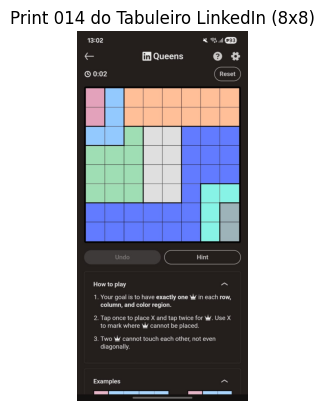

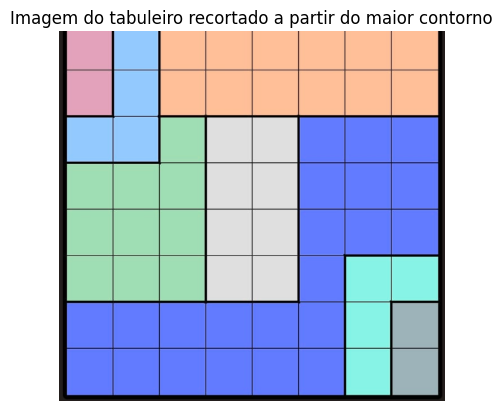


Mapeamento dos quadradinhos (matriz):
[[6 4 3 3 3 3 3 3]
 [6 4 3 3 3 3 3 3]
 [4 4 2 1 1 0 0 0]
 [2 2 2 1 1 0 0 0]
 [2 2 2 1 1 0 0 0]
 [2 2 2 1 1 0 5 5]
 [0 0 0 0 0 0 5 7]
 [0 0 0 0 0 0 5 7]]


Quantidade de conflitos: 4

########################################################################




In [60]:
def pipeline():
  for id_imagem in range(1, QUANTIDADE_IMAGENS+1):
    print("########################################################################")
    print(f"####################### MAPEAMENTO TABULEIRO {id_imagem:03d} #######################")
    print("########################################################################\n")
    # função que carrega as imagens (prints) do tabuleiro
    print_tabuleiro = carregar_imagens_tabuleiro(id_imagem)
    print("\n")
    # função que recorta a região de interesse (tabuleiro) do print automaticamente
    tabuleiro_recortado = recortar_imagem_tabuleiro(print_tabuleiro)
    # função que gera a matriz de cores do tabuleiro a partir da imagem do tabuleiro
    matriz_tabuleiro = gerar_matriz_tabuleiro(tabuleiro_recortado)
    # estado aleatório para teste
        # colunas: indice do vetor
        # linhas: valor em cada indice
    estado = [1, 3, 4, 7, 0, 2, 5, 6]
    # função que calcula conflitos de rainhas no tabuleiro
    conflitos = calcular_conflitos(estado, matriz_tabuleiro)
    print("########################################################################\n\n")

pipeline()